### 1.从感知机到神经网络

由感知机知道，感知机存在很多可能性，但是权重参数设计非常困难，而神经网络的其中一个性质就是可以自动的从数据中学习合适的参数

神经网络由三部分组成，输入层，中间层，以及中间的隐藏层，但不是代表着只有三层，之间的关系类似于多层感知机的实现，层层传递，不过我们将w1x1+w2x2+b用h(x)来代替,x>0,h(x)=1,x<=0,h(x)=0,将h(x)称为激活函数。

激活函数是区分感知机和神经网络的重要指标，感知机所采用的是阶跃函数，即超过某个值，就切换输出值，而我们将阶跃函数换成其他函数，就进入神经网络世界！

### 2.激活函数

2.1 sigmoid函数

h(x)=1/1+exp(-x)
其中exp(-x)表示e的-x次方，由函数性质可知，sigmoid函数是连续平滑的曲线，且取值在0到一之间

2.2 阶跃函数的实现

In [ ]:
from pandas.core.interchange.from_dataframe import primitive_column_to_ndarray
from twisted.persisted.aot import indentify


def step_function(x):
    if(x>0):
        return 1
    else:
        return 0


非常简单，但是这样不能对数组进行操作，要求传入参数必须是实数，为便于操作，我们需要用numpy解决

In [3]:
import numpy as np
x=np.array([-1.0,1.0,2.0])
y=x>0
print(y)
y=y.astype(int)
print(y)


[False  True  True]
[0 1 1]


上面的例子用了numpy的性质，用数组比较一个数，会返回元素个数相同的数组，符合条件的为True，否则为False，但是我们需要的是整数而不是bool类型，所以y=y.astype(int)作类型转换

2.3 sigmoid函数的实现

In [4]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
x=np.array([-1.0,1.0,2.0])
y=sigmoid(x)
print(y)

[0.26894142 0.73105858 0.88079708]


2.4 直观的用图像对比阶跃函数和sigmoid函数

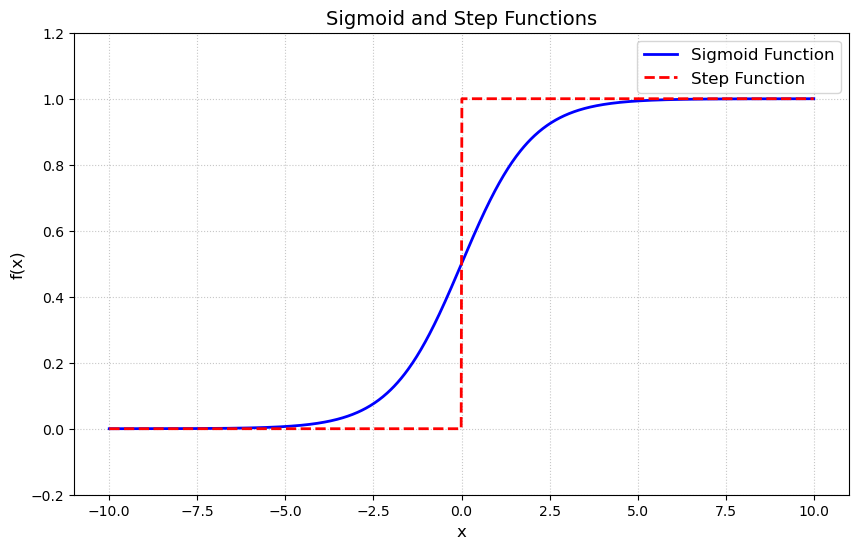

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成数据
# 在 -10 到 10 之间生成 1000 个点，使曲线更平滑
x = np.linspace(-10, 10, 1000)

# 计算 Sigmoid 函数值
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
y_sigmoid = sigmoid(x)

# 计算阶跃函数值 (当 x >= 0 时为 1，否则为 0)
y_step = np.heaviside(x, 1)

# 2. 绘制图像
plt.figure(figsize=(10, 6))

# 绘制 Sigmoid 函数
plt.plot(x, y_sigmoid, label='Sigmoid Function', color='blue', linewidth=2)

# 绘制阶跃函数 (使用虚线表示)
plt.plot(x, y_step, label='Step Function', color='red', linestyle='--', linewidth=2)

# 3. 美化图表
plt.title('Sigmoid and Step Functions', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(fontsize=12)  # 显示图例
plt.grid(True, linestyle=':', alpha=0.7)  # 添加网格
plt.ylim(-0.2, 1.2)  # 设置y轴范围，让图像上下留白更好看

# 显示图像
plt.show()


sigmoid函数和阶跃函数都是非线性函数，所谓线性就是指如y=kx的函数，神经网络中的激活函数不能使用线性函数，因为假设一个三层的神经网络，三次的结果只是c³x，完全可以用y=c³x代替，失去了隐藏层，无法发挥神经网络的优势

2.5 Relu函数
非常简单大于零时返回本身，否则返回零


In [8]:
def relu(x):
    return np.maximum(0,x)


### 3.多层神经网络的实现

下一层的神经元是由上一层的神经元经由激活函数得来，如果有偏置要加上偏置(原理不便文字记录，最好还是看书)，下面是代码实现

In [11]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def init_network():
    network = {}
    network['w1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['w2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['w3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])
    return network

def identity_function(x):
    return x

def forward(network, x):
    w1 = network['w1']
    b1 = network['b1']
    w2 = network['w2']
    b2 = network['b2']
    w3 = network['w3']
    b3 = network['b3']
    a1 = np.dot(x, w1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, w2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, w3) + b3
    y = identity_function(a3)
    return y

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]


### 4.输出层的设计

神经网络的应用主要是回归问题和分类问题，由于这两种问题的特性，我们需要不同的激活函数，回归问题就用恒等函数，而分类问题用softmax函数，下面是介绍

1.恒等函数：原封不动的输出输入值。

2.softmax函数：
$$
ext{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{k=1}^{K} e^{z_k}}
$$
我们可以由公式知道，输出层的每一个神经元都受到上一层所有神经元的影响，而且所有输出层元素的和为1，这是一个非常有用的性质，我们先用代码实现：

In [12]:
import numpy as np
a=np.array([0.3,2.9,4.0])
exp_a=np.exp(a)
print(exp_a)
sum=np.sum(exp_a)
print(sum)
y=exp_a/sum
print(y)

[ 1.34985881 18.17414537 54.59815003]
74.1221542101633
[0.01821127 0.24519181 0.73659691]


同时我们注意到，由于指数函数的增长性，当x值相当大时，数据有溢出风险，所以我们可以采取分子分母同除法缩小数据，结果如下：
$$
\text{Softmax}(z_i) = \frac{e^{z_i - \max(\mathbf{z})}}{\sum_{k=1}^{K} e^{z_k - \max(\mathbf{z})}}
$$

我们减去最大值，能保证数据始终处于安全范围内

### 2.2 softmax函数的特征

刚刚说到了softmax具有和为1，且非负的性质，这使得我们可以将其与概率联系起来，事实上也是这样，当输入数据大时，所对应的神经元也会更大，会占更多比例，概率自然也会越大，这使我们可以很好的处理分类问题(多个类型的数据计算后，概率最大的那个是正确的分类)

## ！！！！应用！！！！！

### 利用神经网络实现手写数字识别

1. 首先要引入MNIST数据集，里面有数以万计的手写数字图像用来训练机器学习，下面要导入它

In [1]:
from mnist import load_mnist
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)#调MNIST库,首次调用会花一点时间，后面这个时函数，括号里面是参数，用来正规化图像
print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

Done
Done
Done
Done
Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


下面我们来真的看看这个图片

In [5]:
from mnist import load_mnist
import numpy as np
from PIL import Image#PIL是python里面的图像显示模块
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True,normalize=False)#flattern=ture意思是把28*28的数组，展开成784维的一维数组，normalize=False，不做归一化，保持像素值为0~255的整数
def img_show(img):
    pil_img=Image.fromarray(np.uint8(img))#Image.fromarray()的作用是把numpy数组格式的数据，转换为PIL库能识别的图片对象
    pil_img.show()#显示图片的方法
img=x_train[0]
label=t_train[0]
print(label)#这里会输出5，说明这张图片就是5.
print(img.shape)
img=img.reshape(28,28)#还原回28*28的数组，不然PLI不能接收显示
print(img.shape)
img_show(img)#调用

5
(784,)
(28, 28)


### 原理

神经网络是如何实现这个的呢：首先从结构上分析，由于图片数据是由28*28组成，所以输入层共有784个元素，而输出层则有10个元素，分别是0到9。这个神经网络还有两个隐藏层，下面先定义三个函数

In [ ]:
def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test
#作用是得到数据

def init_network():
    with open("sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)#假设学习已经完成，pickle文件以字典的形式保存了权重参数和偏置，我们要做的就是取出来
    return network
#作用是取出学习后的权重参数和偏置

def predict(network, x):
    w1, w2, w3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, w1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, w2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, w3) + b3
    y = softmax(a3)#前面有soft函数的实现，这里不再多写

    return y
#神经网络向前推进的方法

有了上述三个函数，就可以实现神经网络的推理处理

In [8]:

x,t=get_data()#x获取数据集中的图片，t表示图片对应的正确数字
network=init_network()#获取训练好的权重和偏置
accuracy=0#初始化
for i in range(len(x)):#len(x)是对所有图片遍历
    y=predict(network, x)#进行预测，得到的y是一个数组十个元素，分别表示0~9的概率
    p=np.argmax(y)#取出概率最大的元素，即预测结果
    if p==t[i]:
        accuracy+=1#预测正确加一
print("accuracy:"+str(float(accuracy/len(x))))



FileNotFoundError: [Errno 2] No such file or directory: 'sample_weight.pkl'

在上述代码中运用for结构，依次对每一张图片识别操作，它的维度变化是784-50-100-10(50和100为中间隐藏层的维度，可以任意取，10是最后表示概率的一维数组)。如果我们想一次处理完一百张图片呢，这时候用到批处理

实际上，想一次处理100张图片很简单，当你输入时，一张图片仍然是784维的，不过有一个百个，中间过程并无变化，只是最后输出时，输出的是100个一维数组，下面是代码实现：

In [ ]:
x,t=get_data()#x获取数据集中的图片，t表示图片对应的正确数字
network=init_network()#获取训练好的权重和偏置
batchsize=100#批量数
accuracy=0#初始化
for i in range(0,len(x),batchsize):#batchsize作为步长，保证每一次循环中的x，t取到的是该图片对应数组的第一个元素
    x_batch=x[i:i+batchsize]
    y_batch=predict(network, x_batch)
    p=np.argmax(y_batch, axis=1)
    accuracy+=np.sum(p==t[i:i+batchsize])
print("accuracy:"+str(float(accuracy/len(x))))

理解起来稍微有点困难，必须要掌握x，t的本质才能更好理解，x是一个二维数组,行列数为(图片个数，784),每一个图片都是以784个更小的元素组成，而t表示的是一维数组，大小为图片张数，理解完这个，x_batch这一句就是切出了batch个元素，作为这一批的处理对象，由于函数的特性，y_batch函数在接收x_batch作为的参数后，其形式是一个(batch,10)的矩阵,每一行表示的就是一张图片的概率预测值，而下一行就是在y_baych的每一行中选出概率最大值，即是每一章图片的结果，p就是100个元素的一维数组，下一行就是将p中的每一个元素与正确答案比较并累加正确结果。

### 批处理可以高速且高效地处理数据，应当注意使用